# Big Data Storage Management — Storage Analysis

**Purpose:** Understand what drives storage growth, where storage is concentrated, and which file-generation patterns create optimization opportunities.

This notebook is organized as a data story: **How big is the environment? → Where is the storage? → What is driving file growth? → Where are the small/large file patterns? → What should be investigated first?**

## 1. Start with the analytical dataset

**Question:** What data are we analyzing, and is it ready for the storage story?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

INPUT_FILE = "/home/sina/bigdata-lab/storage_lab/metadata/metadata_clean.parquet"

df = pd.read_parquet(INPUT_FILE)

print(f"Rows    : {len(df):,}")
print(f"Columns : {len(df.columns)}")


In [2]:
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("DataType"))

print("\nSample:")
display(df.head())


Dataset shape: (4942657, 25)

Columns:
['Source', 'Zone', 'TableName', 'LogicalTableName', 'FileName', 'FileFormat', 'TotalSizeBytes', 'FileCount', 'IsPartitioned', 'PartitionColumn', 'PartitionName', 'PartitionPattern', 'HasHourlyPartition', 'HourlyPartitionName', 'ModificationTimestamp', 'ModificationDate', 'ModificationTime', 'Year', 'Month', 'Day', 'YearMonth', 'Hour', 'ParentPath', 'FullPath', 'Type']

Data types:


,DataType
Source,str
Zone,str
TableName,str
LogicalTableName,str
FileName,str
FileFormat,str
TotalSizeBytes,int64
FileCount,int64
IsPartitioned,bool
PartitionColumn,str



Sample:


,Source,Zone,TableName,LogicalTableName,FileName,FileFormat,TotalSizeBytes,FileCount,IsPartitioned,PartitionColumn,PartitionName,PartitionPattern,HasHourlyPartition,HourlyPartitionName,ModificationTimestamp,ModificationDate,ModificationTime,Year,Month,Day,YearMonth,Hour,ParentPath,FullPath,Type
0,source_04,BRONZE,sales_detail,sales_detail,sales_detail_00005.dat,dat,135266304,1,False,NaN,NaN,NaN,False,NaN,2026-09-29 15:21:45,2026-09-29,15:21:45,2026,9,29,2026-09,15,/home/sina/bigdata-lab/storage_lab/bronze/sour...,/home/sina/bigdata-lab/storage_lab/bronze/sour...,dat
1,source_04,BRONZE,sales_detail,sales_detail,sales_detail_00004.dat,dat,128974848,1,False,NaN,NaN,NaN,False,NaN,2026-09-29 15:49:15,2026-09-29,15:49:15,2026,9,29,2026-09,15,/home/sina/bigdata-lab/storage_lab/bronze/sour...,/home/sina/bigdata-lab/storage_lab/bronze/sour...,dat
2,source_04,BRONZE,sales_detail,sales_detail,sales_detail_00007.dat,dat,117440512,1,False,NaN,NaN,NaN,False,NaN,2026-09-29 15:43:32,2026-09-29,15:43:32,2026,9,29,2026-09,15,/home/sina/bigdata-lab/storage_lab/bronze/sour...,/home/sina/bigdata-lab/storage_lab/bronze/sour...,dat
3,source_04,BRONZE,sales_detail,sales_detail,sales_detail_00002.dat,dat,114294784,1,False,NaN,NaN,NaN,False,NaN,2026-09-30 15:02:31,2026-09-30,15:02:31,2026,9,30,2026-09,15,/home/sina/bigdata-lab/storage_lab/bronze/sour...,/home/sina/bigdata-lab/storage_lab/bronze/sour...,dat
4,source_04,BRONZE,sales_detail,sales_detail,sales_detail_00009.dat,dat,115343360,1,False,NaN,NaN,NaN,False,NaN,2026-06-22 15:43:37,2026-06-22,15:43:37,2026,6,22,2026-06,15,/home/sina/bigdata-lab/storage_lab/bronze/sour...,/home/sina/bigdata-lab/storage_lab/bronze/sour...,dat


## 2. How big is the storage environment?

**Question:** What is the overall storage footprint and file population?

In [ ]:
print("=" * 70)
print("STORAGE OVERVIEW")
print("=" * 70)

total_storage_bytes = df["TotalSizeBytes"].sum()
total_files = df["FileCount"].sum()

average_file_size_mb = (
    df.loc[df["FileCount"] > 0, "TotalSizeBytes"].mean()
    / (1024 ** 2)
)

median_file_size_mb = (
    df.loc[df["FileCount"] > 0, "TotalSizeBytes"].median()
    / (1024 ** 2)
)

min_file_size_mb = (
    df.loc[df["FileCount"] > 0, "TotalSizeBytes"].min()
    / (1024 ** 2)
)

max_file_size_mb = (
    df.loc[df["FileCount"] > 0, "TotalSizeBytes"].max()
    / (1024 ** 2)
)

print(f"Total Storage       : {total_storage_bytes / (1024**3):,.2f} GB")
print(f"Total Files         : {total_files:,}")
print(f"Average File Size   : {average_file_size_mb:,.2f} MB")
print(f"Median File Size    : {median_file_size_mb:,.2f} MB")
print(f"Minimum File Size   : {min_file_size_mb:,.2f} MB")
print(f"Maximum File Size   : {max_file_size_mb:,.2f} MB")


In [ ]:
print(f"Sources             : {df['Source'].nunique():,}")
print(f"Tables              : {df['TableName'].nunique():,}")
print(f"File Formats        : {df['FileFormat'].nunique():,}")


## 3. Is storage growth driven by volume, file count, or both?

**Question:** How do storage and file count evolve over time, and do they tell the same story?

In [ ]:
monthly_storage = (
    df.groupby("YearMonth")
      .agg(
          StorageBytes=("TotalSizeBytes", "sum"),
          FileCount=("FileCount", "sum"),
          TableCount=("TableName", "nunique")
      )
      .reset_index()
)

monthly_storage["StorageGB"] = (
    monthly_storage["StorageBytes"] / (1024 ** 3)
)

monthly_storage["StorageTB"] = (
    monthly_storage["StorageBytes"] / (1024 ** 4)
)

monthly_storage


In [ ]:
monthly_storage["StorageGrowthGB"] = (
    monthly_storage["StorageGB"].diff()
)

monthly_storage["FileCountGrowth"] = (
    monthly_storage["FileCount"].diff()
)

display(monthly_storage)


In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_storage["YearMonth"],
    monthly_storage["StorageGB"],
    marker="o"
)

plt.title("Monthly Storage Growth")
plt.xlabel("Month")
plt.ylabel("Storage (GB)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_storage["YearMonth"],
    monthly_storage["FileCount"],
    marker="o"
)

plt.title("Monthly File Count Growth")
plt.xlabel("Month")
plt.ylabel("File Count")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# -----------------------------
# Storage Growth
# -----------------------------
axes[0].plot(
    monthly_storage["YearMonth"],
    monthly_storage["StorageGB"],
    marker="o"
)

axes[0].set_title("Monthly Storage Growth")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Storage (GB)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(True, alpha=0.3)


# -----------------------------
# File Count Growth
# -----------------------------
axes[1].plot(
    monthly_storage["YearMonth"],
    monthly_storage["FileCount"],
    marker="o"
)

axes[1].set_title("Monthly File Count Growth")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("File Count")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()


## 4. Where is the storage concentrated?

**Question:** Which sources contribute most of the storage footprint and file population?

In [3]:
source_storage = (
    df.groupby("Source")
      .agg(
          StorageBytes=("TotalSizeBytes", "sum"),
          FileCount=("FileCount", "sum"),
          TableCount=("TableName", "nunique")
      )
      .reset_index()
)

source_storage["StorageGB"] = (
    source_storage["StorageBytes"] / (1024 ** 3)
)

source_storage["StorageTB"] = (
    source_storage["StorageBytes"] / (1024 ** 4)
)

source_storage["StorageSharePct"] = (
    source_storage["StorageBytes"]
    / source_storage["StorageBytes"].sum()
    * 100
)

source_storage = source_storage.sort_values(
    "StorageBytes",
    ascending=False
)

display(source_storage)


,Source,StorageBytes,FileCount,TableCount,StorageGB,StorageTB,StorageSharePct
0,source_01,15084670681088,747146,5,14048.694336,13.719428,16.077086
2,source_03,14004208533504,768979,5,13042.435547,12.736753,14.925541
1,source_02,13797483872256,759403,5,12849.908203,12.548738,14.705216
5,source_06,13697510539264,759012,5,12756.800781,12.457813,14.598665
8,source_09,7364777345024,385838,5,6858.983398,6.698226,7.849303
3,source_04,7234586148864,373882,5,6737.733398,6.579818,7.710547
7,source_08,7124680704000,387758,5,6635.375977,6.479859,7.593411
9,source_10,7074467545088,382677,5,6588.611328,6.434191,7.539894
6,source_07,7032004411392,376257,5,6549.064453,6.395571,7.494638
4,source_05,1412754833408,1705,5,1315.730469,1.284893,1.505699


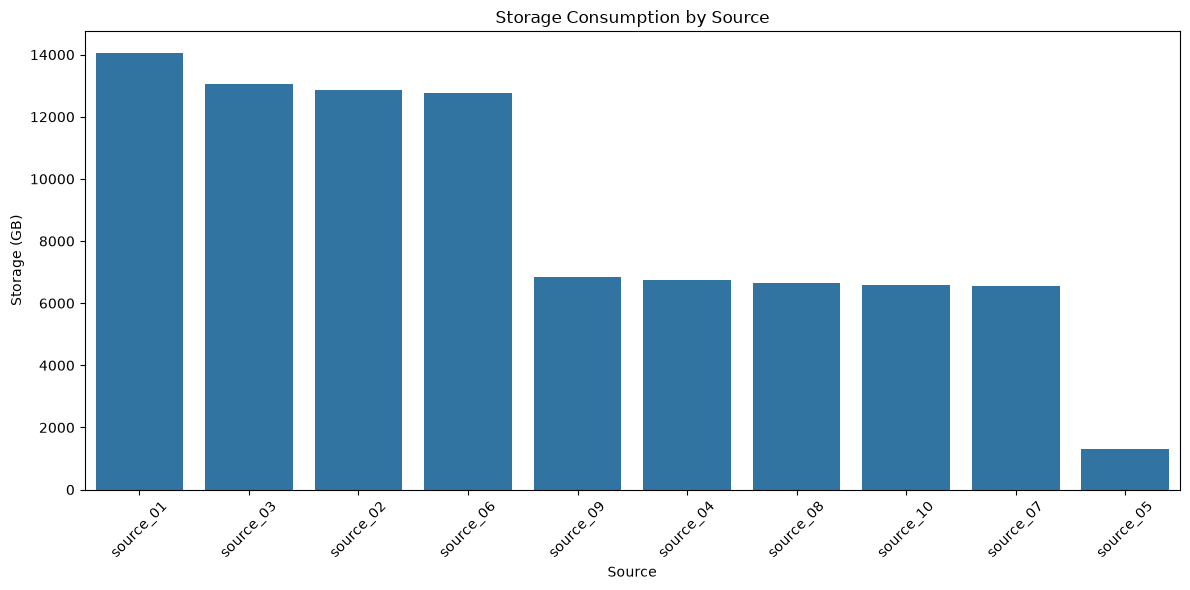

In [4]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=source_storage,
    x="Source",
    y="StorageGB"
)

plt.title("Storage Consumption by Source")
plt.xlabel("Source")
plt.ylabel("Storage (GB)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


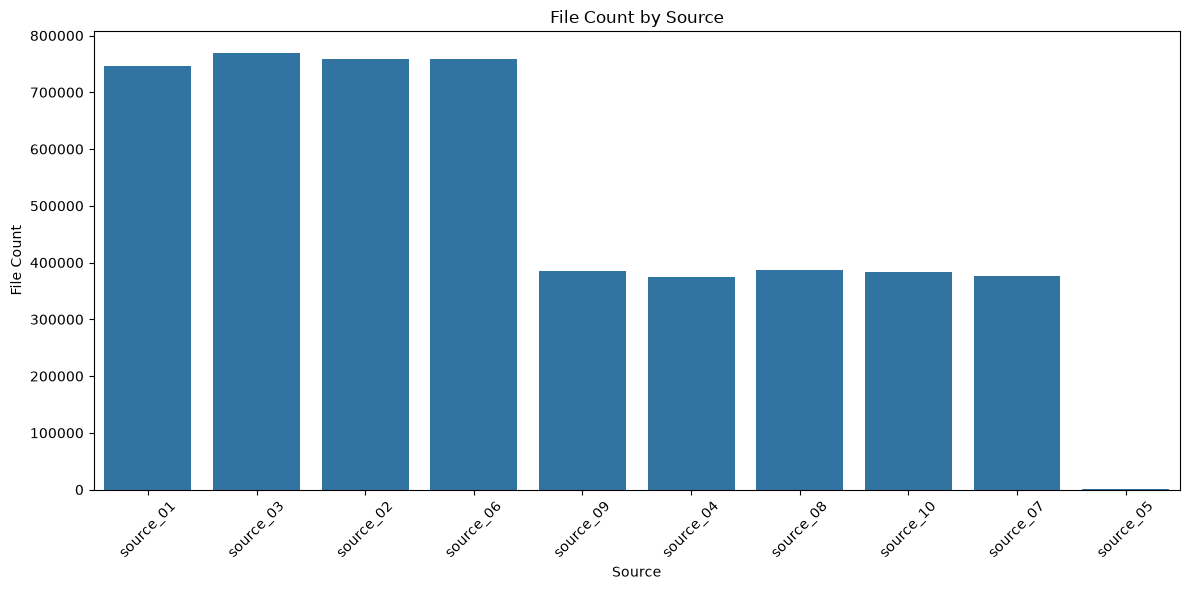

In [5]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=source_storage,
    x="Source",
    y="FileCount"
)

plt.title("File Count by Source")
plt.xlabel("Source")
plt.ylabel("File Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 5. Which tables drive the footprint?

**Question:** Which tables combine significant storage, file count, or unusual file-size behavior?

In [6]:
table_storage = (
    df.groupby(["Source", "TableName"])
      .agg(
          StorageBytes=("TotalSizeBytes", "sum"),
          FileCount=("FileCount", "sum"),
          MedianFileSizeBytes=("TotalSizeBytes", "median")
      )
      .reset_index()
)

table_storage["StorageGB"] = (
    table_storage["StorageBytes"] / (1024 ** 3)
)

table_storage["StorageTB"] = (
    table_storage["StorageBytes"] / (1024 ** 4)
)

table_storage["MedianFileSizeMB"] = (
    table_storage["MedianFileSizeBytes"] / (1024 ** 2)
)

table_storage["StorageSharePct"] = (
    table_storage["StorageBytes"]
    / table_storage["StorageBytes"].sum()
    * 100
)

table_storage = table_storage.sort_values(
    "StorageBytes",
    ascending=False
)

display(
    table_storage[
        [
            "Source",
            "TableName",
            "StorageGB",
            "FileCount",
            "MedianFileSizeMB",
            "StorageSharePct"
        ]
    ].head(20)
)


,Source,TableName,StorageGB,FileCount,MedianFileSizeMB,StorageSharePct
18,source_04,sales_order,6346.310547,369756,16.0,7.262609
12,source_03,network_sessions,6319.532227,383246,16.0,7.231965
10,source_03,network_events,6317.716797,381484,16.0,7.229887
8,source_02,payment_events,6266.474609,379892,16.0,7.171247
35,source_08,service_event,6248.019531,383653,16.0,7.150127
41,source_09,analytics_event,6245.840820,380674,16.0,7.147634
25,source_06,application_event,6227.210938,381225,16.0,7.126314
6,source_02,billing_transaction,6196.129883,375432,16.0,7.090745
46,source_10,operations_event,6185.741211,378385,16.0,7.078857
33,source_07,marketing_event,6159.054688,372060,16.0,7.048317


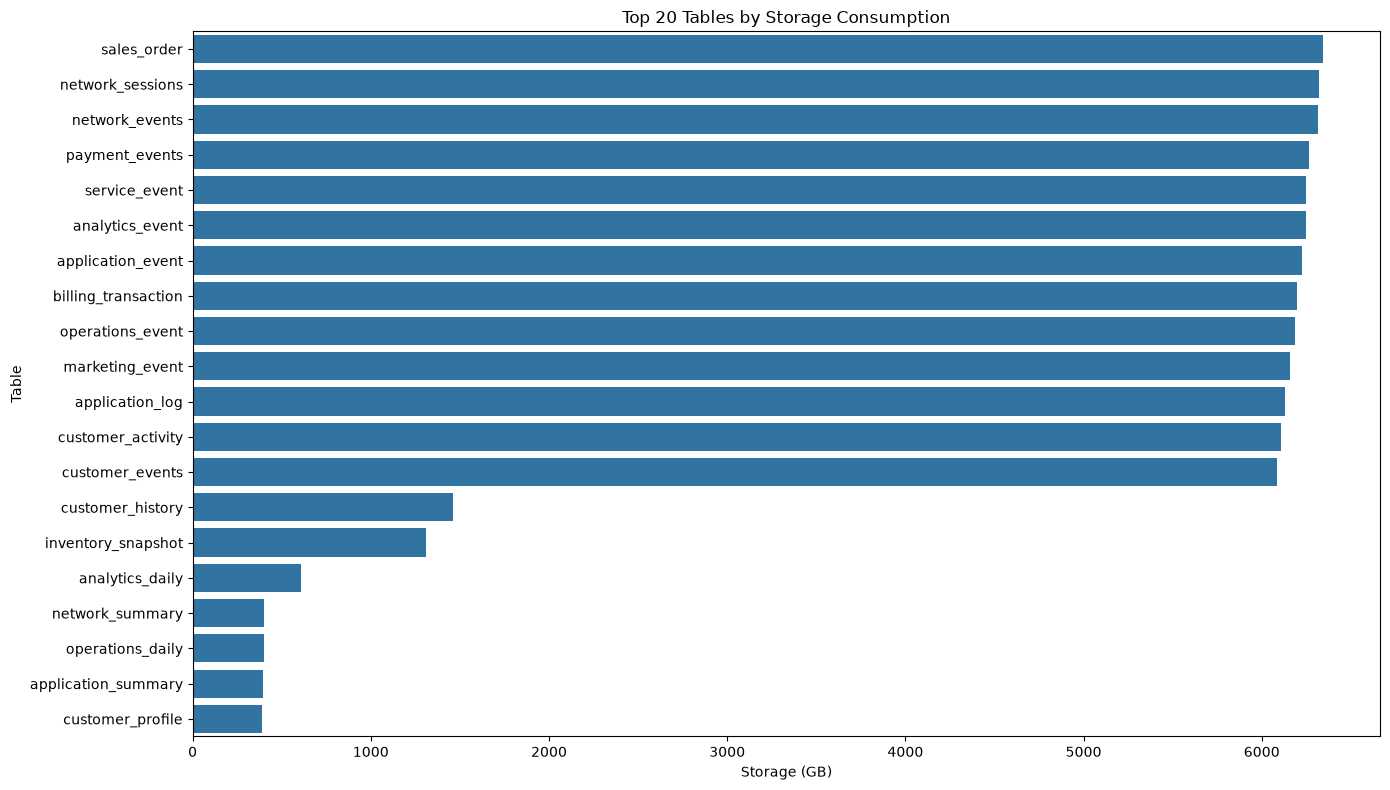

In [7]:
top_tables = table_storage.head(20)

plt.figure(figsize=(14, 8))

sns.barplot(
    data=top_tables,
    x="StorageGB",
    y="TableName"
)

plt.title("Top 20 Tables by Storage Consumption")
plt.xlabel("Storage (GB)")
plt.ylabel("Table")
plt.tight_layout()
plt.show()


In [8]:
table_storage = (
    df.groupby(["Source", "TableName"])
      .agg(
          StorageBytes=("TotalSizeBytes", "sum"),
          FileCount=("FileCount", "sum"),
          AverageFileSizeBytes=("TotalSizeBytes", "mean"),
          MedianFileSizeBytes=("TotalSizeBytes", "median")
      )
      .reset_index()
)

table_storage["StorageGB"] = (
    table_storage["StorageBytes"] / (1024 ** 3)
)

table_storage["AverageFileSizeMB"] = (
    table_storage["AverageFileSizeBytes"] / (1024 ** 2)
)

table_storage["MedianFileSizeMB"] = (
    table_storage["MedianFileSizeBytes"] / (1024 ** 2)
)

table_storage["StorageSharePct"] = (
    table_storage["StorageBytes"]
    / table_storage["StorageBytes"].sum()
    * 100
)

table_storage = table_storage.sort_values(
    "StorageBytes",
    ascending=False
)

display(
    table_storage[
        [
            "Source",
            "TableName",
            "StorageGB",
            "FileCount",
            "AverageFileSizeMB",
            "MedianFileSizeMB",
            "StorageSharePct"
        ]
    ].head(20)
)


,Source,TableName,StorageGB,FileCount,AverageFileSizeMB,MedianFileSizeMB,StorageSharePct
18,source_04,sales_order,6346.310547,369756,17.575434,16.0,7.262609
12,source_03,network_sessions,6319.532227,383246,16.885241,16.0,7.231965
10,source_03,network_events,6317.716797,381484,16.958357,16.0,7.229887
8,source_02,payment_events,6266.474609,379892,16.891301,16.0,7.171247
35,source_08,service_event,6248.019531,383653,16.676455,16.0,7.150127
41,source_09,analytics_event,6245.840820,380674,16.801098,16.0,7.147634
25,source_06,application_event,6227.210938,381225,16.726773,16.0,7.126314
6,source_02,billing_transaction,6196.129883,375432,16.900096,16.0,7.090745
46,source_10,operations_event,6185.741211,378385,16.740090,16.0,7.078857
33,source_07,marketing_event,6159.054688,372060,16.951223,16.0,7.048317


## 6. What does the file-size distribution look like?

**Question:** Is the environment dominated by appropriately sized files, small files, or large files?

In [9]:
# ============================================================
# 2.6 File Size Distribution
# ============================================================

# Work only with actual file records.
# Empty directories have FileCount = 0.
file_df = df[df["FileCount"] > 0].copy()


# ------------------------------------------------------------
# 1. Convert file size from Bytes to MB
# ------------------------------------------------------------
file_df["FileSizeMB"] = (
    file_df["TotalSizeBytes"] / (1024 ** 2)
)


# ------------------------------------------------------------
# 2. Classify files by size
# ------------------------------------------------------------
def classify_file_size(size_mb):

    if size_mb < 60:
        return "<60 MB"

    elif size_mb < 90:
        return "60–90 MB"

    elif size_mb < 100:
        return "90–100 MB"

    elif size_mb < 200:
        return "100–200 MB"

    elif size_mb < 300:
        return "200–300 MB"

    elif size_mb < 400:
        return "300–400 MB"

    elif size_mb < 500:
        return "400–500 MB"

    elif size_mb < 600:
        return "500–600 MB"

    elif size_mb < 700:
        return "600–700 MB"

    elif size_mb < 800:
        return "700–800 MB"

    elif size_mb < 900:
        return "800–900 MB"

    elif size_mb < 1000:
        return "900–1000 MB"

    elif size_mb < 1100:
        return "1000–1100 MB"

    elif size_mb < 1200:
        return "1100–1200 MB"

    elif size_mb < 1300:
        return "1200–1300 MB"

    elif size_mb < 1400:
        return "1300–1400 MB"

    elif size_mb < 1500:
        return "1400–1500 MB"

    elif size_mb < 1600:
        return "1500–1600 MB"

    elif size_mb < 1700:
        return "1600–1700 MB"

    elif size_mb < 1800:
        return "1700–1800 MB"

    elif size_mb < 1900:
        return "1800–1900 MB"

    elif size_mb < 2000:
        return "1900–2000 MB"

    elif size_mb < 2100:
        return "2000–2100 MB"

    elif size_mb < 2200:
        return "2100–2200 MB"

    elif size_mb < 2300:
        return "2200–2300 MB"

    elif size_mb < 2400:
        return "2300–2400 MB"

    elif size_mb < 2500:
        return "2400–2500 MB"

    else:
        return ">2500 MB"


file_df["FileSizeCategory"] = (
    file_df["FileSizeMB"].apply(classify_file_size)
)


# ------------------------------------------------------------
# 3. Define category order
# ------------------------------------------------------------
category_order = [
    "<60 MB",
    "60–90 MB",
    "90–100 MB",
    "100–200 MB",
    "200–300 MB",
    "300–400 MB",
    "400–500 MB",
    "500–600 MB",
    "600–700 MB",
    "700–800 MB",
    "800–900 MB",
    "900–1000 MB",
    "1000–1100 MB",
    "1100–1200 MB",
    "1200–1300 MB",
    "1300–1400 MB",
    "1400–1500 MB",
    "1500–1600 MB",
    "1600–1700 MB",
    "1700–1800 MB",
    "1800–1900 MB",
    "1900–2000 MB",
    "2000–2100 MB",
    "2100–2200 MB",
    "2200–2300 MB",
    "2300–2400 MB",
    "2400–2500 MB",
    ">2500 MB"
]

file_df["FileSizeCategory"] = pd.Categorical(
    file_df["FileSizeCategory"],
    categories=category_order,
    ordered=True
)


# ------------------------------------------------------------
# 4. Aggregate by Table, Year and File Size Category
# ------------------------------------------------------------
size_distribution = (
    file_df
    .groupby(
        ["TableName", "Year", "FileSizeCategory"],
        observed=True,
        as_index=False
    )
    .agg(
        FileCount=("FileCount", "sum"),
        TotalSizeBytes=("TotalSizeBytes", "sum")
    )
)


# ------------------------------------------------------------
# 5. Calculate yearly totals
# ------------------------------------------------------------
year_totals = (
    file_df
    .groupby("Year", as_index=False)
    .agg(
        YearTotalFileCount=("FileCount", "sum"),
        YearTotalSizeBytes=("TotalSizeBytes", "sum")
    )
)


# ------------------------------------------------------------
# 6. Add yearly totals
# ------------------------------------------------------------
size_distribution = size_distribution.merge(
    year_totals,
    on="Year",
    how="left"
)


# ------------------------------------------------------------
# 7. Calculate percentages
# ------------------------------------------------------------

# File count percentage of all files in the year
size_distribution["FileCountPercentOfYear"] = (
    size_distribution["FileCount"]
    / size_distribution["YearTotalFileCount"]
    * 100
)

# Storage percentage of all storage in the year
size_distribution["StoragePercentOfYear"] = (
    size_distribution["TotalSizeBytes"]
    / size_distribution["YearTotalSizeBytes"]
    * 100
)


# ------------------------------------------------------------
# 8. Convert storage units
# ------------------------------------------------------------
size_distribution["TotalSizeGB"] = (
    size_distribution["TotalSizeBytes"]
    / (1024 ** 3)
)

size_distribution["TotalSizeTB"] = (
    size_distribution["TotalSizeBytes"]
    / (1024 ** 4)
)

size_distribution["YearTotalSizeGB"] = (
    size_distribution["YearTotalSizeBytes"]
    / (1024 ** 3)
)

size_distribution["YearTotalSizeTB"] = (
    size_distribution["YearTotalSizeBytes"]
    / (1024 ** 4)
)


# ------------------------------------------------------------
# 9. Final column order
# ------------------------------------------------------------
size_distribution = size_distribution[
    [
        "TableName",
        "Year",
        "FileSizeCategory",
        "FileCount",
        "YearTotalFileCount",
        "FileCountPercentOfYear",
        "TotalSizeBytes",
        "TotalSizeGB",
        "TotalSizeTB",
        "StoragePercentOfYear",
        "YearTotalSizeGB",
        "YearTotalSizeTB"
    ]
]


# ------------------------------------------------------------
# 10. Sort result
# ------------------------------------------------------------
size_distribution = (
    size_distribution
    .sort_values(
        ["Year", "TableName", "FileSizeCategory"]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 11. Display formatted result
# ------------------------------------------------------------
display(
    size_distribution.style.format({
        "FileCount": "{:,.0f}",
        "YearTotalFileCount": "{:,.0f}",
        "FileCountPercentOfYear": "{:.2f}%",
        "TotalSizeBytes": "{:,.0f}",
        "TotalSizeGB": "{:,.2f}",
        "TotalSizeTB": "{:,.2f}",
        "StoragePercentOfYear": "{:.2f}%",
        "YearTotalSizeGB": "{:,.2f}",
        "YearTotalSizeTB": "{:,.2f}"
    })
)


,TableName,Year,FileSizeCategory,FileCount,YearTotalFileCount,FileCountPercentOfYear,TotalSizeBytes,TotalSizeGB,TotalSizeTB,StoragePercentOfYear,YearTotalSizeGB,YearTotalSizeTB
0,analytics_daily,2024,<60 MB,101,"1,485,542",0.01%,"5,624,561,664",5.24,0.01,0.02%,"26,887.42",26.26
1,analytics_daily,2024,60–90 MB,589,"1,485,542",0.04%,"46,678,409,216",43.47,0.04,0.16%,"26,887.42",26.26
2,analytics_daily,2024,90–100 MB,199,"1,485,542",0.01%,"19,650,314,240",18.30,0.02,0.07%,"26,887.42",26.26
3,analytics_daily,2024,100–200 MB,575,"1,485,542",0.04%,"79,589,015,552",74.12,0.07,0.28%,"26,887.42",26.26
4,analytics_daily,2024,200–300 MB,237,"1,485,542",0.02%,"62,206,771,200",57.93,0.06,0.22%,"26,887.42",26.26
5,analytics_daily,2024,300–400 MB,1,"1,485,542",0.00%,"314,572,800",0.29,0.00,0.00%,"26,887.42",26.26
6,analytics_event,2024,<60 MB,"112,335","1,485,542",7.56%,"2,038,468,444,160","1,898.47",1.85,7.06%,"26,887.42",26.26
7,application_event,2024,<60 MB,"113,773","1,485,542",7.66%,"2,045,152,067,584","1,904.70",1.86,7.08%,"26,887.42",26.26
8,application_log,2024,<60 MB,"113,183","1,485,542",7.62%,"2,054,123,683,840","1,913.05",1.87,7.12%,"26,887.42",26.26
9,application_summary,2024,<60 MB,98,"1,485,542",0.01%,"5,422,186,496",5.05,0.00,0.02%,"26,887.42",26.26


## 7. Are small files the dominant pattern?

**Question:** How many small files exist, how much storage do they represent, and where are they concentrated?

In [11]:
# ============================================================
# 2.7 Small File Analysis
# ============================================================

# Small files are defined as files smaller than 60 MB.
small_files = file_df[file_df["FileSizeMB"] < 60].copy()

print("=" * 70)
print("SMALL FILE OVERVIEW")
print("=" * 70)

small_file_count = small_files["FileCount"].sum()
small_file_storage = small_files["TotalSizeBytes"].sum()

total_file_count = file_df["FileCount"].sum()
total_storage = file_df["TotalSizeBytes"].sum()

small_file_count_pct = (
    small_file_count / total_file_count * 100
)

small_file_storage_pct = (
    small_file_storage / total_storage * 100
)

print(f"Small Files          : {small_file_count:,}")
print(f"Small File Storage    : {small_file_storage / (1024**3):,.2f} GB")
print(f"File Count Share      : {small_file_count_pct:.2f}%")
print(f"Storage Share         : {small_file_storage_pct:.2f}%")


SMALL FILE OVERVIEW
Small Files          : 4,902,206
Small File Storage    : 80,742.68 GB
File Count Share      : 99.18%
Storage Share         : 92.40%


In [12]:
# ------------------------------------------------------------
# Small files by table
# ------------------------------------------------------------

small_file_by_table = (
    small_files
    .groupby(
        ["Source", "TableName"],
        as_index=False
    )
    .agg(
        SmallFileCount=("FileCount", "sum"),
        SmallFileStorageBytes=("TotalSizeBytes", "sum")
    )
)

small_file_by_table["SmallFileStorageGB"] = (
    small_file_by_table["SmallFileStorageBytes"]
    / (1024 ** 3)
)

small_file_by_table["SmallFilePercentOfTable"] = (
    small_file_by_table["SmallFileCount"]
    /
    small_file_by_table["TableName"]
       .map(
           file_df.groupby("TableName")["FileCount"].sum()
       )
    * 100
)

small_file_by_table = small_file_by_table.sort_values(
    "SmallFileCount",
    ascending=False
)

display(
    small_file_by_table.head(20).style.format({
        "SmallFileCount": "{:,.0f}",
        "SmallFileStorageBytes": "{:,.0f}",
        "SmallFileStorageGB": "{:,.2f}",
        "SmallFilePercentOfTable": "{:.2f}%"
    })
)


,Source,TableName,SmallFileCount,SmallFileStorageBytes,SmallFileStorageGB,SmallFilePercentOfTable
27,source_08,service_event,"383,653","6,708,759,887,872","6,248.02",100.00%
10,source_03,network_sessions,"383,246","6,785,546,059,776","6,319.53",100.00%
8,source_03,network_events,"381,484","6,783,596,756,992","6,317.72",100.00%
18,source_06,application_event,"381,225","6,686,416,830,464","6,227.21",100.00%
31,source_09,analytics_event,"380,674","6,706,420,514,816","6,245.84",100.00%
6,source_02,payment_events,"379,892","6,728,575,877,120","6,266.47",100.00%
35,source_10,operations_event,"378,385","6,641,889,050,624","6,185.74",100.00%
5,source_02,billing_transaction,"375,432","6,653,043,802,112","6,196.13",100.00%
19,source_06,application_log,"373,595","6,584,115,658,752","6,131.94",100.00%
0,source_01,customer_activity,"373,009","6,560,504,872,960","6,109.95",100.00%


In [ ]:
# ------------------------------------------------------------
# Top 20 tables by small-file count
# ------------------------------------------------------------

top_small_file_tables = (
    small_file_by_table
    .head(20)
)

plt.figure(figsize=(14, 8))

sns.barplot(
    data=top_small_file_tables,
    x="SmallFileCount",
    y="TableName"
)

plt.title("Top 20 Tables by Small File Count")
plt.xlabel("Small File Count")
plt.ylabel("Table")

plt.tight_layout()
plt.show()


## 8. What about large files?

**Question:** Are large files a major storage driver, or a smaller localized pattern?

In [13]:
# ============================================================
# 2.8 Large File Analysis
# ============================================================

# Large files are defined as files larger than 500 MB.
large_files = file_df[
    file_df["FileSizeMB"] > 500
].copy()


print("=" * 70)
print("LARGE FILE OVERVIEW")
print("=" * 70)

large_file_count = large_files["FileCount"].sum()
large_file_storage = large_files["TotalSizeBytes"].sum()

total_file_count = file_df["FileCount"].sum()
total_storage = file_df["TotalSizeBytes"].sum()

large_file_count_pct = (
    large_file_count
    / total_file_count
    * 100
)

large_file_storage_pct = (
    large_file_storage
    / total_storage
    * 100
)

print(f"Large Files          : {large_file_count:,}")
print(f"Large File Storage    : {large_file_storage / (1024**3):,.2f} GB")
print(f"File Count Share      : {large_file_count_pct:.2f}%")
print(f"Storage Share         : {large_file_storage_pct:.2f}%")


LARGE FILE OVERVIEW
Large Files          : 3,129
Large File Storage    : 2,702.61 GB
File Count Share      : 0.06%
Storage Share         : 3.09%


In [ ]:
# ------------------------------------------------------------
# Large files by table
# ------------------------------------------------------------

large_file_by_table = (
    large_files
    .groupby(
        ["Source", "TableName"],
        as_index=False
    )
    .agg(
        LargeFileCount=("FileCount", "sum"),
        LargeFileStorageBytes=("TotalSizeBytes", "sum")
    )
)

large_file_by_table["LargeFileStorageGB"] = (
    large_file_by_table["LargeFileStorageBytes"]
    / (1024 ** 3)
)

table_file_counts = (
    file_df
    .groupby("TableName")["FileCount"]
    .sum()
)

large_file_by_table["LargeFilePercentOfTable"] = (
    large_file_by_table["LargeFileCount"]
    / large_file_by_table["TableName"].map(table_file_counts)
    * 100
)

large_file_by_table = large_file_by_table.sort_values(
    "LargeFileStorageBytes",
    ascending=False
)

display(
    large_file_by_table.head(20).style.format({
        "LargeFileCount": "{:,.0f}",
        "LargeFileStorageBytes": "{:,.0f}",
        "LargeFileStorageGB": "{:,.2f}",
        "LargeFilePercentOfTable": "{:.2f}%"
    })
)


In [ ]:
# ------------------------------------------------------------
# Top 20 tables by large-file storage
# ------------------------------------------------------------

top_large_file_tables = (
    large_file_by_table
    .head(20)
)

plt.figure(figsize=(14, 8))

sns.barplot(
    data=top_large_file_tables,
    x="LargeFileStorageGB",
    y="TableName"
)

plt.title("Top 20 Tables by Large File Storage")
plt.xlabel("Large File Storage (GB)")
plt.ylabel("Table")

plt.tight_layout()
plt.show()


In [ ]:
# ------------------------------------------------------------
# Top 20 tables by large-file count
# ------------------------------------------------------------

top_large_file_count = (
    large_file_by_table
    .sort_values("LargeFileCount", ascending=False)
    .head(20)
)

plt.figure(figsize=(14, 8))

sns.barplot(
    data=top_large_file_count,
    x="LargeFileCount",
    y="TableName"
)

plt.title("Top 20 Tables by Large File Count")
plt.xlabel("Large File Count")
plt.ylabel("Table")

plt.tight_layout()
plt.show()


## 9. Where should optimization investigation start?

**Question:** Which tables deserve attention when storage, file count, and file-size concentration are considered together?

In [ ]:
# ============================================================
# 2.9 Storage Optimization Ranking
# ============================================================

# ------------------------------------------------------------
# 1. Overall table-level storage metrics
# ------------------------------------------------------------

optimization = (
    file_df
    .groupby(
        ["Source", "TableName"],
        as_index=False
    )
    .agg(
        TotalStorageBytes=("TotalSizeBytes", "sum"),
        TotalFileCount=("FileCount", "sum"),
        MedianFileSizeMB=("FileSizeMB", "median"),
        MinFileSizeMB=("FileSizeMB", "min"),
        MaxFileSizeMB=("FileSizeMB", "max")
    )
)


# ------------------------------------------------------------
# 2. Small-file metrics
# ------------------------------------------------------------

small_metrics = (
    small_files
    .groupby(
        ["Source", "TableName"],
        as_index=False
    )
    .agg(
        SmallFileCount=("FileCount", "sum"),
        SmallFileStorageBytes=("TotalSizeBytes", "sum")
    )
)


# ------------------------------------------------------------
# 3. Large-file metrics
# ------------------------------------------------------------

large_metrics = (
    large_files
    .groupby(
        ["Source", "TableName"],
        as_index=False
    )
    .agg(
        LargeFileCount=("FileCount", "sum"),
        LargeFileStorageBytes=("TotalSizeBytes", "sum")
    )
)


# ------------------------------------------------------------
# 4. Merge small and large file metrics
# ------------------------------------------------------------

optimization = optimization.merge(
    small_metrics,
    on=["Source", "TableName"],
    how="left"
)

optimization = optimization.merge(
    large_metrics,
    on=["Source", "TableName"],
    how="left"
)


# Tables without small/large files get zero
optimization[
    [
        "SmallFileCount",
        "SmallFileStorageBytes",
        "LargeFileCount",
        "LargeFileStorageBytes"
    ]
] = optimization[
    [
        "SmallFileCount",
        "SmallFileStorageBytes",
        "LargeFileCount",
        "LargeFileStorageBytes"
    ]
].fillna(0)


# ------------------------------------------------------------
# 5. Calculate percentages
# ------------------------------------------------------------

optimization["SmallFilePercent"] = (
    optimization["SmallFileCount"]
    / optimization["TotalFileCount"]
    * 100
)

optimization["LargeFilePercent"] = (
    optimization["LargeFileCount"]
    / optimization["TotalFileCount"]
    * 100
)

optimization["StorageSharePercent"] = (
    optimization["TotalStorageBytes"]
    / optimization["TotalStorageBytes"].sum()
    * 100
)


# ------------------------------------------------------------
# 6. Convert storage units
# ------------------------------------------------------------

optimization["TotalStorageGB"] = (
    optimization["TotalStorageBytes"]
    / (1024 ** 3)
)

optimization["TotalStorageTB"] = (
    optimization["TotalStorageBytes"]
    / (1024 ** 4)
)

optimization["SmallFileStorageGB"] = (
    optimization["SmallFileStorageBytes"]
    / (1024 ** 3)
)

optimization["LargeFileStorageGB"] = (
    optimization["LargeFileStorageBytes"]
    / (1024 ** 3)
)


# ------------------------------------------------------------
# 7. Sort by storage consumption
# ------------------------------------------------------------

optimization = optimization.sort_values(
    "TotalStorageBytes",
    ascending=False
).reset_index(drop=True)


# ------------------------------------------------------------
# 8. Final columns
# ------------------------------------------------------------

optimization = optimization[
    [
        "Source",
        "TableName",
        "TotalStorageGB",
        "TotalStorageTB",
        "StorageSharePercent",
        "TotalFileCount",
        "MedianFileSizeMB",
        "MinFileSizeMB",
        "MaxFileSizeMB",
        "SmallFileCount",
        "SmallFilePercent",
        "SmallFileStorageGB",
        "LargeFileCount",
        "LargeFilePercent",
        "LargeFileStorageGB"
    ]
]


# ------------------------------------------------------------
# 9. Display top tables by storage
# ------------------------------------------------------------

display(
    optimization.head(20).style.format({
        "TotalStorageGB": "{:,.2f}",
        "TotalStorageTB": "{:,.2f}",
        "StorageSharePercent": "{:.2f}%",
        "TotalFileCount": "{:,.0f}",
        "MedianFileSizeMB": "{:,.2f}",
        "MinFileSizeMB": "{:,.2f}",
        "MaxFileSizeMB": "{:,.2f}",
        "SmallFileCount": "{:,.0f}",
        "SmallFilePercent": "{:.2f}%",
        "SmallFileStorageGB": "{:,.2f}",
        "LargeFileCount": "{:,.0f}",
        "LargeFilePercent": "{:.2f}%",
        "LargeFileStorageGB": "{:,.2f}"
    })
)


In [ ]:
# ------------------------------------------------------------
# Top tables by small-file concentration
# ------------------------------------------------------------

small_file_ranking = optimization.sort_values(
    ["SmallFilePercent", "SmallFileCount"],
    ascending=[False, False]
)

display(
    small_file_ranking[
        [
            "Source",
            "TableName",
            "TotalFileCount",
            "SmallFileCount",
            "SmallFilePercent",
            "TotalStorageGB",
            "SmallFileStorageGB"
        ]
    ].head(20).style.format({
        "TotalFileCount": "{:,.0f}",
        "SmallFileCount": "{:,.0f}",
        "SmallFilePercent": "{:.2f}%",
        "TotalStorageGB": "{:,.2f}",
        "SmallFileStorageGB": "{:,.2f}"
    })
)


In [ ]:
# ------------------------------------------------------------
# Top tables by large-file concentration
# ------------------------------------------------------------

large_file_ranking = optimization.sort_values(
    ["LargeFilePercent", "LargeFileCount"],
    ascending=[False, False]
)

display(
    large_file_ranking[
        [
            "Source",
            "TableName",
            "TotalFileCount",
            "LargeFileCount",
            "LargeFilePercent",
            "TotalStorageGB",
            "LargeFileStorageGB"
        ]
    ].head(20).style.format({
        "TotalFileCount": "{:,.0f}",
        "LargeFileCount": "{:,.0f}",
        "LargeFilePercent": "{:.2f}%",
        "TotalStorageGB": "{:,.2f}",
        "LargeFileStorageGB": "{:,.2f}"
    })
)


In [ ]:
# ------------------------------------------------------------
# Storage vs File Count
# ------------------------------------------------------------

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=optimization,
    x="TotalFileCount",
    y="TotalStorageGB",
    size="SmallFilePercent",
    sizes=(40, 500),
    alpha=0.7
)

plt.title("Storage Consumption vs File Count")
plt.xlabel("Total File Count")
plt.ylabel("Total Storage (GB)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 10. What does the data tell us?

**Question:** What are the few findings that should be carried into the management story?

In [ ]:
# ============================================================
# 2.10 Key Findings
# ============================================================

print("=" * 70)
print("STORAGE ANALYSIS SUMMARY")
print("=" * 70)

# Overall metrics
total_storage_gb = file_df["TotalSizeBytes"].sum() / (1024 ** 3)
total_storage_tb = file_df["TotalSizeBytes"].sum() / (1024 ** 4)

total_files = file_df["FileCount"].sum()

total_tables = file_df["TableName"].nunique()
total_sources = file_df["Source"].nunique()

# Small files
small_file_count = small_files["FileCount"].sum()
small_file_storage_gb = (
    small_files["TotalSizeBytes"].sum() / (1024 ** 3)
)

small_file_count_pct = (
    small_file_count / total_files * 100
)

small_file_storage_pct = (
    small_files["TotalSizeBytes"].sum()
    / file_df["TotalSizeBytes"].sum()
    * 100
)

# Large files
large_file_count = large_files["FileCount"].sum()
large_file_storage_gb = (
    large_files["TotalSizeBytes"].sum() / (1024 ** 3)
)

large_file_count_pct = (
    large_file_count / total_files * 100
)

large_file_storage_pct = (
    large_files["TotalSizeBytes"].sum()
    / file_df["TotalSizeBytes"].sum()
    * 100
)

print(f"Total Storage       : {total_storage_gb:,.2f} GB")
print(f"Total Storage       : {total_storage_tb:,.2f} TB")
print(f"Total Files         : {total_files:,}")
print(f"Total Sources       : {total_sources:,}")
print(f"Total Tables        : {total_tables:,}")

print("\nSMALL FILES")
print(f"File Count          : {small_file_count:,}")
print(f"File Count Share    : {small_file_count_pct:.2f}%")
print(f"Storage             : {small_file_storage_gb:,.2f} GB")
print(f"Storage Share       : {small_file_storage_pct:.2f}%")

print("\nLARGE FILES")
print(f"File Count          : {large_file_count:,}")
print(f"File Count Share    : {large_file_count_pct:.2f}%")
print(f"Storage             : {large_file_storage_gb:,.2f} GB")
print(f"Storage Share       : {large_file_storage_pct:.2f}%")


In [ ]:
# ------------------------------------------------------------
# Top small-file concentration
# ------------------------------------------------------------

top_small_file_tables = (
    optimization
    .sort_values(
        ["SmallFilePercent", "SmallFileCount"],
        ascending=[False, False]
    )
    .head(10)
)

display(
    top_small_file_tables[
        [
            "Source",
            "TableName",
            "TotalFileCount",
            "SmallFileCount",
            "SmallFilePercent",
            "TotalStorageGB",
            "SmallFileStorageGB"
        ]
    ].style.format({
        "TotalFileCount": "{:,.0f}",
        "SmallFileCount": "{:,.0f}",
        "SmallFilePercent": "{:.2f}%",
        "TotalStorageGB": "{:,.2f}",
        "SmallFileStorageGB": "{:,.2f}"
    })
)


In [ ]:
# ------------------------------------------------------------
# Top large-file concentration
# ------------------------------------------------------------

top_large_file_tables = (
    optimization
    .sort_values(
        ["LargeFilePercent", "LargeFileCount"],
        ascending=[False, False]
    )
    .head(10)
)

display(
    top_large_file_tables[
        [
            "Source",
            "TableName",
            "TotalFileCount",
            "LargeFileCount",
            "LargeFilePercent",
            "TotalStorageGB",
            "LargeFileStorageGB"
        ]
    ].style.format({
        "TotalFileCount": "{:,.0f}",
        "LargeFileCount": "{:,.0f}",
        "LargeFilePercent": "{:.2f}%",
        "TotalStorageGB": "{:,.2f}",
        "LargeFileStorageGB": "{:,.2f}"
    })
)


## Conclusion

The analysis turns metadata into a practical view of storage consumption, file-generation behavior, and optimization opportunities.